# Notebook 2 — Ball Tracking (TrackNet)

**TFM: Análisis de tenis mediante Computer Vision**

Objetivo: entrenar una red **TrackNet** (encoder VGG-like + decoder con upsampling y skip connections) sobre el dataset TrackNet de tenis, y exportar las posiciones predichas de la pelota a `outputs/tracking/ball_positions.csv`.

**Entrada al modelo:** 3 frames consecutivos apilados como tensor (9 canales).  
**Salida:** heatmap 2D centrado en la pelota (gaussiano, σ=5px).  
**Resolución de trabajo:** 640×360.  
**Split:** 80/20 por clip (sin mezclar frames de un mismo clip entre train y val).

Requisitos para ejecutar: `Kernel → Restart & Run All`.

## Índice

1. Configuración
2. Exploración del dataset
3. Dataset PyTorch
4. Arquitectura TrackNet
5. Entrenamiento
6. Inferencia sobre el clip de prueba
7. Exportar CSV

In [9]:
# ── Stdlib ──
import random
import re
import time
import warnings
from pathlib import Path

# ── Numérico / datos ──
import numpy as np
import pandas as pd

# ── Visión artificial ──
import cv2

# ── Deep learning ──
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models

# ── Visualización ──
import matplotlib.pyplot as plt

## 1. Configuración

In [2]:
# ----- Rutas -----
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "Dataset"
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"
MODELS_OUT = OUTPUTS_ROOT / "models"
TRACKING_OUT = OUTPUTS_ROOT / "tracking"
MODELS_OUT.mkdir(parents=True, exist_ok=True)
TRACKING_OUT.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_OUT / "tracknet_best.pth"
OUTPUT_CSV = TRACKING_OUT / "ball_positions.csv"

# ----- Dataset / preprocesado -----
INPUT_W = 640
INPUT_H = 360
N_INPUT_FRAMES = 3              # apilar 3 frames consecutivos -> 9 canales
GAUSSIAN_SIGMA = 5.0             # σ del heatmap objetivo (en píxeles de INPUT_W x INPUT_H)
VAL_SPLIT = 0.20
RANDOM_SEED = 42

# ----- Entrenamiento -----
BATCH_SIZE = 8
LR = 1e-4
EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
NUM_WORKERS = 0                  # 0 en Windows para evitar problemas con multiprocessing

# ----- Inferencia -----
INFER_GAME = "game1"
INFER_CLIP = "Clip1"
HEATMAP_THRESHOLD = 0.5          # umbral para considerar pelota detectada

# ----- Device -----
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    warnings.warn(
        "No se ha detectado GPU. El entrenamiento será MUY lento en CPU; "
        "considera reducir EPOCHS o entrenar en una máquina con GPU.",
        stacklevel=2,
    )
    print("Ejecutando en CPU.")

torch.manual_seed(RANDOM_SEED)
print(f"Dataset: {DATASET_ROOT}")
print(f"Modelo se guardará en: {BEST_MODEL_PATH}")

C:\Users\cosme\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3699: UserWarning: No se ha detectado GPU. El entrenamiento será MUY lento en CPU; considera reducir EPOCHS o entrenar en una máquina con GPU.
  exec(code_obj, self.user_global_ns, self.user_ns)


Ejecutando en CPU.
Dataset: c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\Dataset
Modelo se guardará en: c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\models\tracknet_best.pth


## 2. Exploración del dataset

In [3]:
def find_clip_dirs(dataset_root: Path):
    """Devuelve la lista de directorios de clips que contienen un Label.csv."""
    clips = []
    for game_dir in sorted(dataset_root.iterdir()):
        if not game_dir.is_dir() or not game_dir.name.lower().startswith("game"):
            continue
        for clip_dir in sorted(game_dir.iterdir()):
            if clip_dir.is_dir() and (clip_dir / "Label.csv").exists():
                clips.append(clip_dir)
    return clips

clip_dirs = find_clip_dirs(DATASET_ROOT)
print(f"Clips encontrados: {len(clip_dirs)}")

# Cargar todos los Label.csv y concatenarlos para exploración global
all_labels = []
for c in clip_dirs:
    df = pd.read_csv(c / "Label.csv")
    df["clip"] = f"{c.parent.name}/{c.name}"
    all_labels.append(df)
labels = pd.concat(all_labels, ignore_index=True)
labels.columns = [col.strip() for col in labels.columns]
print(f"Imágenes totales: {len(labels)}")
print(f"Visibility=1:    {(labels['visibility'] == 1).sum()}")
print(f"Visibility=0:    {(labels['visibility'] == 0).sum()}")
print(f"Rebotes (status=1): {(labels['status'] == 1).sum()}")
labels.head()

Clips encontrados: 76
Imágenes totales: 15045
Visibility=1:    13292
Visibility=0:    647
Rebotes (status=1): 393


,file name,visibility,x-coordinate,y-coordinate,status,clip
0,0000.jpg,1,599.0,423.0,0.0,game1/Clip1
1,0001.jpg,1,601.0,406.0,0.0,game1/Clip1
2,0002.jpg,1,601.0,388.0,0.0,game1/Clip1
3,0003.jpg,1,598.0,371.0,0.0,game1/Clip1
4,0004.jpg,1,598.0,353.0,0.0,game1/Clip1


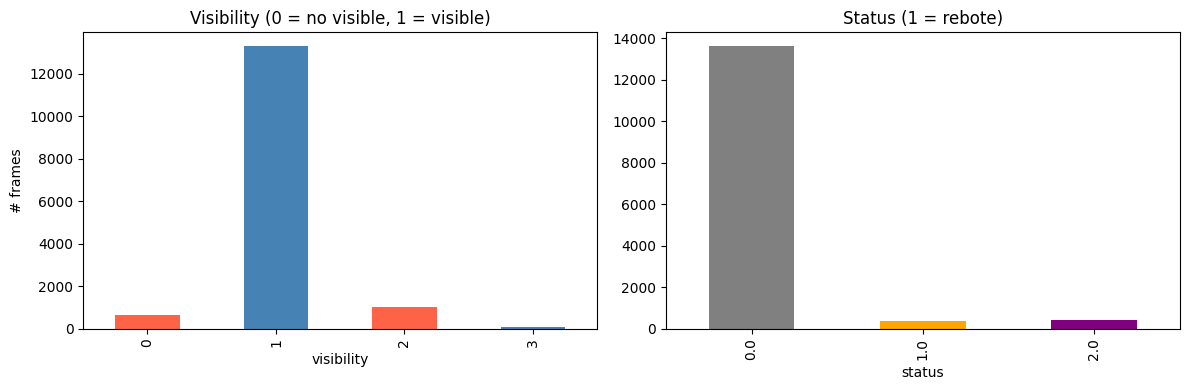

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels["visibility"].value_counts().sort_index().plot.bar(ax=axes[0], color=["tomato", "steelblue"])
axes[0].set_title("Visibility (0 = no visible, 1 = visible)")
axes[0].set_xlabel("visibility")
axes[0].set_ylabel("# frames")

labels["status"].value_counts().sort_index().plot.bar(ax=axes[1], color=["gray", "orange", "purple", "green"])
axes[1].set_title("Status (1 = rebote)")
axes[1].set_xlabel("status")
plt.tight_layout()
plt.show()

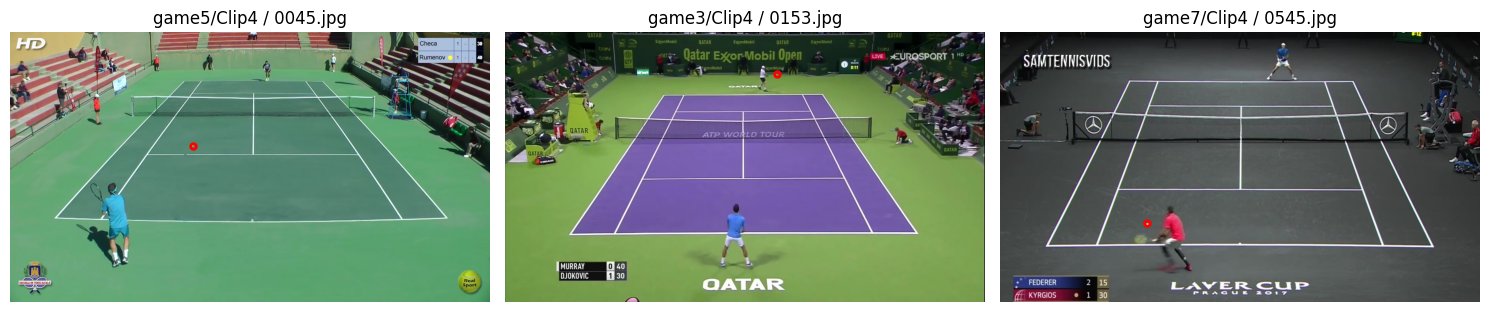

In [6]:
# 3 ejemplos de frames con pelota visible y su posición marcada
visible = labels[labels["visibility"] == 1].sample(3, random_state=RANDOM_SEED)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (_, row) in zip(axes, visible.iterrows()):
    img_path = DATASET_ROOT / row["clip"] / row["file name"]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.plot(row["x-coordinate"], row["y-coordinate"], "o", markersize=4,
            markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)
    ax.set_title(f"{row['clip']} / {row['file name']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset PyTorch

Cada muestra:
- **Input:** 3 frames consecutivos `(t-2, t-1, t)` redimensionados a 640×360 y apilados como tensor `(9, H, W)` (RGB×3, normalizado a `[0, 1]`).
- **Output:** heatmap gaussiano `(1, H, W)` centrado en `(x, y)` del frame `t`, con σ=5px en la resolución de trabajo.

Se excluyen ventanas en las que algún frame de los 3 tenga `visibility=0`. El split 80/20 se hace **por clip completo** para evitar fugas.

In [7]:
def make_gaussian_heatmap(h, w, cx, cy, sigma):
    """Heatmap 2D gaussiano normalizado a [0, 1] (pico = 1)."""
    ys = np.arange(h, dtype=np.float32)[:, None]
    xs = np.arange(w, dtype=np.float32)[None, :]
    return np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2.0 * sigma ** 2)).astype(np.float32)


class TrackNetDataset(Dataset):
    """Devuelve (input_9ch, heatmap_1ch, meta) para entrenamiento de TrackNet."""

    def __init__(self, samples, dataset_root, input_w, input_h, sigma, n_frames=3):
        self.samples = samples              # lista de dicts con info por muestra
        self.dataset_root = dataset_root
        self.input_w = input_w
        self.input_h = input_h
        self.sigma = sigma
        self.n_frames = n_frames

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        frames = []
        for fname in s["frame_files"]:
            img = cv2.imread(str(self.dataset_root / s["clip"] / fname))
            if img is None:
                raise FileNotFoundError(self.dataset_root / s["clip"] / fname)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            orig_h, orig_w = img.shape[:2]
            img = cv2.resize(img, (self.input_w, self.input_h), interpolation=cv2.INTER_AREA)
            frames.append(img.astype(np.float32) / 255.0)
        # (3 frames, H, W, 3) -> apilar canales -> (9, H, W)
        x = np.concatenate([f.transpose(2, 0, 1) for f in frames], axis=0)

        # Reescalar coordenadas de la pelota (del frame t) a la resolución de trabajo
        cx = s["x"] * (self.input_w / orig_w)
        cy = s["y"] * (self.input_h / orig_h)
        hm = make_gaussian_heatmap(self.input_h, self.input_w, cx, cy, self.sigma)

        return (
            torch.from_numpy(x),                       # (9, H, W)
            torch.from_numpy(hm).unsqueeze(0),         # (1, H, W)
            {"clip": s["clip"], "target_frame": s["frame_files"][-1]},
        )


def build_samples(clip_dirs, n_frames=3):
    """Construye la lista de muestras (ventanas de n_frames consecutivos con visibility=1 en todos)."""
    samples_by_clip = {}
    for clip_dir in clip_dirs:
        df = pd.read_csv(clip_dir / "Label.csv")
        df.columns = [c.strip() for c in df.columns]
        df = df.sort_values("file name").reset_index(drop=True)
        clip_key = f"{clip_dir.parent.name}/{clip_dir.name}"
        clip_samples = []
        for i in range(n_frames - 1, len(df)):
            window = df.iloc[i - n_frames + 1 : i + 1]
            if (window["visibility"] == 1).all():
                target = window.iloc[-1]
                clip_samples.append({
                    "clip": clip_key,
                    "frame_files": window["file name"].tolist(),
                    "x": float(target["x-coordinate"]),
                    "y": float(target["y-coordinate"]),
                    "status": int(target["status"]),
                })
        if clip_samples:
            samples_by_clip[clip_key] = clip_samples
    return samples_by_clip

samples_by_clip = build_samples(clip_dirs, n_frames=N_INPUT_FRAMES)
total_samples = sum(len(v) for v in samples_by_clip.values())
print(f"Clips con muestras: {len(samples_by_clip)}")
print(f"Muestras válidas (todas visibility=1 en la ventana): {total_samples}")

Clips con muestras: 76
Muestras válidas (todas visibility=1 en la ventana): 11757


In [8]:
# Split por clip (80/20) sin mezclar frames de un mismo clip entre splits
rng = random.Random(RANDOM_SEED)
all_clip_keys = sorted(samples_by_clip.keys())
rng.shuffle(all_clip_keys)
n_val_clips = max(1, int(round(len(all_clip_keys) * VAL_SPLIT)))
val_clips = set(all_clip_keys[:n_val_clips])
train_clips = set(all_clip_keys[n_val_clips:])

train_samples = [s for k in train_clips for s in samples_by_clip[k]]
val_samples = [s for k in val_clips for s in samples_by_clip[k]]
print(f"Clips train: {len(train_clips)} | muestras: {len(train_samples)}")
print(f"Clips val:   {len(val_clips)} | muestras: {len(val_samples)}")

train_ds = TrackNetDataset(train_samples, DATASET_ROOT, INPUT_W, INPUT_H, GAUSSIAN_SIGMA, N_INPUT_FRAMES)
val_ds = TrackNetDataset(val_samples, DATASET_ROOT, INPUT_W, INPUT_H, GAUSSIAN_SIGMA, N_INPUT_FRAMES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

x_sample, y_sample, _ = train_ds[0]
print(f"Tensor entrada: {tuple(x_sample.shape)} | heatmap: {tuple(y_sample.shape)} | pico HM: {y_sample.max():.3f}")

Clips train: 61 | muestras: 9694
Clips val:   15 | muestras: 2063
Tensor entrada: (9, 360, 640) | heatmap: (1, 360, 640) | pico HM: 0.995


## 4. Arquitectura TrackNet

Encoder **VGG16 preentrenado en ImageNet** adaptado a 9 canales de entrada (3 frames RGB apilados). La primera capa convolucional se reinicializa promediando los pesos originales triplicados para preservar el conocimiento preentrenado. Decoder U-Net con 4 bloques de upsampling y skip connections desde el encoder. Salida: 1 canal sigmoide del mismo tamaño que la entrada.

In [10]:
class TrackNetV2(nn.Module):
    """TrackNet con encoder VGG16 preentrenado adaptado a 9 canales de entrada."""

    def __init__(self, in_channels=9, out_channels=1):
        super().__init__()

        vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
        feats = list(vgg.features.children())

        # Adapt first conv: 3 -> in_channels, averaging pretrained weights
        orig_conv = feats[0]
        new_first = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        with torch.no_grad():
            new_first.weight.data = orig_conv.weight.data.repeat(1, 3, 1, 1) / 3.0
            new_first.bias.data = orig_conv.bias.data.clone()
        feats[0] = new_first

        # Encoder blocks — skip connections taken before each MaxPool
        self.enc1 = nn.Sequential(*feats[0:4])    # 64ch,  H×W
        self.pool1 = feats[4]
        self.enc2 = nn.Sequential(*feats[5:9])    # 128ch, H/2
        self.pool2 = feats[9]
        self.enc3 = nn.Sequential(*feats[10:16])  # 256ch, H/4
        self.pool3 = feats[16]
        self.enc4 = nn.Sequential(*feats[17:23])  # 512ch, H/8
        self.pool4 = feats[23]
        self.bottleneck = nn.Sequential(*feats[24:30])  # 512ch, H/16 (omit pool5)

        # Freeze all encoder except enc1[0] (first conv, adapts to 9ch)
        for name, param in self.enc1.named_parameters():
            if not name.startswith("0."):
                param.requires_grad = False
        for enc in [self.enc2, self.enc3, self.enc4, self.bottleneck]:
            for param in enc.parameters():
                param.requires_grad = False

        # Decoder: Upsample + 2×(Conv-BN-ReLU) with U-Net skip connections
        self.dec4 = self._conv_block(512 + 512, 512)
        self.dec3 = self._conv_block(512 + 256, 256)
        self.dec2 = self._conv_block(256 + 128, 128)
        self.dec1 = self._conv_block(128 + 64,  64)
        self.head = nn.Conv2d(64, out_channels, kernel_size=1)

    @staticmethod
    def _conv_block(in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        s3 = self.enc3(self.pool2(s2))
        s4 = self.enc4(self.pool3(s3))
        b  = self.bottleneck(self.pool4(s4))

        def up(t, ref):
            return F.interpolate(t, size=ref.shape[2:], mode="bilinear", align_corners=False)

        d4 = self.dec4(torch.cat([up(b,  s4), s4], dim=1))
        d3 = self.dec3(torch.cat([up(d4, s3), s3], dim=1))
        d2 = self.dec2(torch.cat([up(d3, s2), s2], dim=1))
        d1 = self.dec1(torch.cat([up(d2, s1), s1], dim=1))

        return torch.sigmoid(self.head(d1))


model = TrackNetV2(in_channels=3 * N_INPUT_FRAMES, out_channels=1).to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = total - train_
print(f"Parámetros totales:     {total  / 1e6:.2f} M")
print(f"Parámetros entrenables: {train_ / 1e6:.2f} M")
print(f"Parámetros congelados:  {frozen / 1e6:.2f} M")
with torch.no_grad():
    dummy = torch.zeros(1, 9, INPUT_H, INPUT_W, device=DEVICE)
    print(f"Salida modelo (dummy): {tuple(model(dummy).shape)}")

Parámetros totales:     24.90 M
Parámetros entrenables: 10.19 M
Parámetros congelados:  14.71 M
Salida modelo (dummy): (1, 1, 360, 640)


## 5. Entrenamiento

Estrategia de **dos fases**:
- **Fase 1** (epochs 1–10): solo se entrenan el decoder y la primera capa conv del encoder (`lr=1e-3`). El resto del encoder VGG16 permanece congelado.
- **Fase 2** (epochs 11–30): se descongela todo el encoder y se realiza fine-tuning completo (`lr=1e-5`).

Loss: MSE entre heatmap predicho y heatmap objetivo. Early stopping (patience=5) sobre `val_loss`. Mejor checkpoint guardado en `outputs/models/tracknet_best.pth`.

In [ ]:
import time

PHASE1_EPOCHS = 10   # epochs 1-10: decoder + primera capa conv
PHASE2_LR     = 1e-5 # fine-tuning lr para el encoder completo

criterion     = nn.MSELoss()
best_val      = float("inf")
patience_count = 0
history       = {"train": [], "val": []}
current_phase = 1

# Fase 1: solo parámetros no congelados (decoder + enc1[0])
optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)


def run_epoch(loader, train, opt):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y, _ in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            pred = model(x)
            loss = criterion(pred, y)
            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()
            total += loss.item() * x.size(0)
            n += x.size(0)
    return total / max(n, 1)


for epoch in range(1, EPOCHS + 1):

    # Cambio automático a Fase 2: descongelar encoder completo
    if epoch == PHASE1_EPOCHS + 1 and current_phase == 1:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=PHASE2_LR)
        current_phase = 2
        print(f"\n--- Fase 2: encoder descongelado, lr={PHASE2_LR} ---\n")

    t0 = time.time()
    tr = run_epoch(train_loader, train=True,  opt=optimizer)
    va = run_epoch(val_loader,   train=False, opt=optimizer)
    history["train"].append(tr)
    history["val"].append(va)
    dt = time.time() - t0
    print(f"[Fase {current_phase}] Epoch {epoch:02d} | train {tr:.5f} | val {va:.5f} | {dt:.1f}s")

    if va < best_val:
        best_val = va
        patience_count = 0
        torch.save({
            "model_state": model.state_dict(),
            "epoch": epoch,
            "val_loss": va,
            "config": {
                "input_w": INPUT_W, "input_h": INPUT_H,
                "n_input_frames": N_INPUT_FRAMES, "sigma": GAUSSIAN_SIGMA,
            },
        }, BEST_MODEL_PATH)
        print(f"  ↳ mejor val_loss, guardado en {BEST_MODEL_PATH.name}")
    else:
        patience_count += 1
        if patience_count >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping en epoch {epoch} (patience={EARLY_STOPPING_PATIENCE})")
            break

print(f"\nMejor val_loss: {best_val:.5f}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(history["train"]) + 1), history["train"], label="train")
ax.plot(range(1, len(history["val"]) + 1), history["val"], label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Curva de entrenamiento — TrackNet")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Inferencia sobre el clip de prueba

Cargamos el mejor checkpoint, predecimos el heatmap frame a frame y extraemos `(x, y)` como el píxel de máxima activación (siempre que supere `HEATMAP_THRESHOLD`). Las coordenadas se devuelven en la **resolución original** del frame.

In [ ]:
ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Checkpoint cargado (epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.5f})")

FRAME_RE = re.compile(r"^\d+\.jpg$", re.IGNORECASE)

def list_frames(clip_dir: Path):
    files = [p for p in clip_dir.iterdir() if FRAME_RE.match(p.name)]
    files.sort(key=lambda p: int(p.stem))
    return files

infer_clip_dir = DATASET_ROOT / INFER_GAME / INFER_CLIP
infer_frames = list_frames(infer_clip_dir)
infer_labels = pd.read_csv(infer_clip_dir / "Label.csv")
infer_labels.columns = [c.strip() for c in infer_labels.columns]
print(f"Inferencia sobre {INFER_GAME}/{INFER_CLIP} — {len(infer_frames)} frames")

In [ ]:
def load_and_prep(path: Path, out_w, out_h):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img.shape[:2]
    img_r = cv2.resize(img, (out_w, out_h), interpolation=cv2.INTER_AREA)
    return img_r.astype(np.float32) / 255.0, (orig_w, orig_h)


def predict_clip(frame_paths, model, device):
    rows = []
    last3 = []
    orig_w = orig_h = None
    for idx, fp in enumerate(frame_paths):
        img_r, (orig_w, orig_h) = load_and_prep(fp, INPUT_W, INPUT_H)
        last3.append(img_r)
        if len(last3) > N_INPUT_FRAMES:
            last3.pop(0)
        if len(last3) < N_INPUT_FRAMES:
            rows.append({"frame": idx, "file": fp.name, "ball_x": np.nan, "ball_y": np.nan,
                          "visibility": 0, "peak": 0.0})
            continue
        x = np.concatenate([f.transpose(2, 0, 1) for f in last3], axis=0)
        x_t = torch.from_numpy(x).unsqueeze(0).to(device)
        with torch.no_grad():
            hm = model(x_t)[0, 0].cpu().numpy()
        peak = float(hm.max())
        if peak >= HEATMAP_THRESHOLD:
            yy, xx = np.unravel_index(np.argmax(hm), hm.shape)
            bx = float(xx) * (orig_w / INPUT_W)
            by = float(yy) * (orig_h / INPUT_H)
            vis = 1
        else:
            bx, by, vis = np.nan, np.nan, 0
        rows.append({"frame": idx, "file": fp.name, "ball_x": bx, "ball_y": by,
                      "visibility": vis, "peak": peak})
    return pd.DataFrame(rows)

pred_df = predict_clip(infer_frames, model, DEVICE)
print(f"Predicciones: {len(pred_df)} | con pelota detectada: {(pred_df['visibility']==1).sum()}")
pred_df.head()

In [ ]:
# 5 frames de ejemplo con predicción (rojo) vs ground truth (verde)
valid = pred_df[pred_df["visibility"] == 1]
show_idx = np.linspace(0, len(valid) - 1, num=min(5, len(valid)), dtype=int)
fig, axes = plt.subplots(1, len(show_idx), figsize=(4 * len(show_idx), 4))
if len(show_idx) == 1:
    axes = [axes]
for ax, i in zip(axes, show_idx):
    row = valid.iloc[i]
    img = cv2.cvtColor(cv2.imread(str(infer_clip_dir / row["file"])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.plot(row["ball_x"], row["ball_y"], "o", markersize=14, markerfacecolor="none",
            markeredgecolor="red", markeredgewidth=2, label="pred")
    gt = infer_labels[infer_labels["file name"] == row["file"]].iloc[0]
    if gt["visibility"] == 1:
        ax.plot(gt["x-coordinate"], gt["y-coordinate"], "x", markersize=14,
                markeredgecolor="lime", markeredgewidth=2, label="gt")
    ax.set_title(f"{row['file']} (peak={row['peak']:.2f})")
    ax.axis("off")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. Exportar CSV

Se construye `ball_positions.csv` con el esquema acordado. `is_bounce` se toma del `status` del `Label.csv` original cuando está disponible para el frame; en frames donde la pelota no se detecta se rellenan `ball_x`, `ball_y` con `NaN` y `visibility=0`.

In [ ]:
gt_map = {row["file name"]: int(row["status"]) for _, row in infer_labels.iterrows()}

out = pd.DataFrame({
    "clip": f"{INFER_GAME}/{INFER_CLIP}",
    "frame": pred_df["frame"],
    "ball_x": pred_df["ball_x"],
    "ball_y": pred_df["ball_y"],
    "visibility": pred_df["visibility"],
    "is_bounce": pred_df["file"].map(gt_map).fillna(0).astype(int),
})
out.to_csv(OUTPUT_CSV, index=False)
print(f"Guardado {len(out)} filas en {OUTPUT_CSV}")
out.head()